# Digit Recognition using ANN from scratch

* Input dimension = 784
* Output classes = 10
* Model type = classifier
* Loss function = cross entropy

## Dataset Description

This project uses the Kaggle Digit Recognizer dataset based on the MNIST handwritten digits dataset.

Each image:
- size: 28 × 28 pixels
- grayscale image
- flattened into a vector of 784 features

The dataset contains:
- pixel values between **0–255**
- label column representing digits **0–9**

Goal:
Train a neural network from scratch using NumPy to classify handwritten digits.

## Importing Lib and reading data

In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [4]:
data = pd.read_csv("digit-recognizer/train.csv")

## Inspecting the Dataset

In [5]:
data.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
31586,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28705,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37929,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39094,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29950,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [7]:
data.shape

(42000, 785)

### Train / Validation Split

The dataset is shuffled and split into:

Training set:
- used to train the neural network

Validation set:
- used to evaluate model performance during training

Split strategy:
- 1000 samples for validation
- remaining samples for training

In [8]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

### Class Distribution

We check whether the dataset is balanced.

A balanced dataset ensures that the model does not become biased toward certain digits.

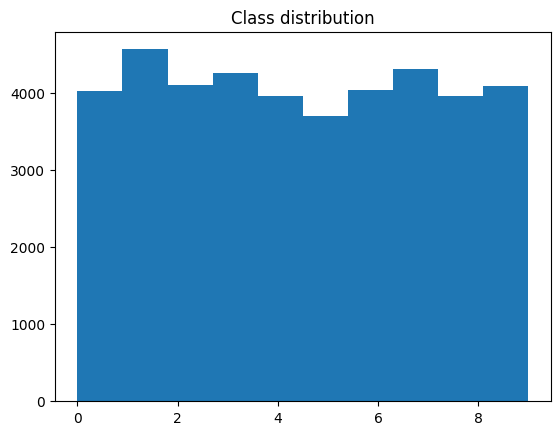

In [9]:
plt.hist(Y_train, bins=10)
plt.title("Class distribution")
plt.show()

### Visualizing Training Images

We visualize a few samples to verify:

- images are correctly loaded
- labels correspond to images
- digit shapes are clear

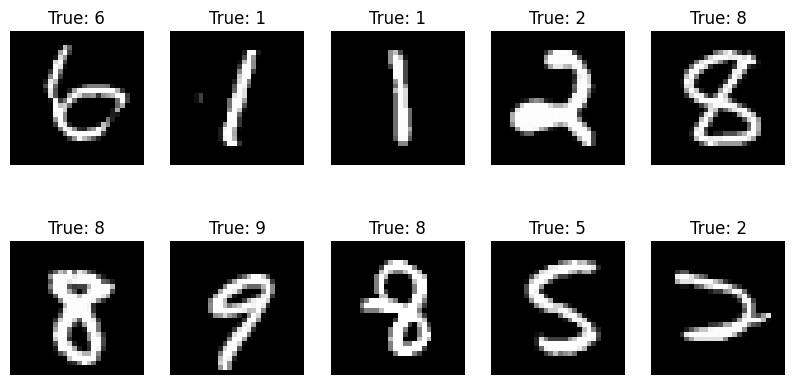

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[:, i].reshape(28, 28), cmap='gray')
    ax.set_title(f"True: {Y_train[i]}")
    ax.axis('off')

plt.show()

## Feature Scaling

Pixel values originally range from **0–255**.

Neural networks train better when inputs are scaled to smaller ranges.

Therefore we normalize the inputs:

0–255 → 0–1

This improves:
- gradient stability
- training convergence

In [12]:
X_train = X_train.astype(np.float32) / 255.0
X_dev = X_dev.astype(np.float32) / 255.0

## Neural Network Architecture

Architecture used:

Input Layer:
- 784 neurons (flattened image pixels)

Hidden Layer:
- 64 neurons
- activation: ReLU

Output Layer:
- 10 neurons
- activation: Softmax

Loss Function:
- Cross Entropy

In [15]:
def inti_params():
    W1 = np.random.randn(64, 784) * np.sqrt(2/784)
    b1 = np.zeros((64,1))

    W2 = np.random.randn(10, 64) * np.sqrt(2/64)
    b2 = np.zeros((10,1))
    
    return W1, b1, W2, b2

'''
def inti_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2
'''

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=0, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def foward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def deriv_ReLU(Z):
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, Y, X):
    m = Y.shape[0]

    one_hot_Y = one_hot(Y)
    
    dZ2 = A2 - one_hot_Y
    dW2 = (dZ2.dot(A1.T)) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = (dZ1.dot(X.T)) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m
    
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

def get_loss(X, Y, A2):
    m = Y.size
    log_likelihood = -np.log(A2[Y, range(m)])
    loss = np.sum(log_likelihood) / m
    return loss

def get_prediction(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, learning_rate):
    W1, b1, W2, b2 = inti_params()

    loss_history = []
    acc_history = []
    
    for i in range(iterations):
        Z1, A1, Z2, A2 = foward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, Y, X)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)
        
        if (i % 10 == 0):
            print("Itreation: ", i)

            loss = get_loss(X, Y, A2) 
            loss_history.append(loss)
            print("Loss: ", loss)

            accuracy = get_accuracy(get_prediction(A2), Y)
            acc_history.append(accuracy)
            print("Accuracy: ", accuracy)
            
            print("------------------------------------------------------------------------------------------------------")
    
    return W1, b1, W2, b2, loss_history, acc_history

### Weight Initialization

We use **He Initialization** for the hidden layer.

Reason:

ReLU activations can suffer from vanishing gradients if weights are too small.

He initialization scales weights using:

√(2 / number_of_inputs)

This helps maintain stable gradient flow during training.

In [18]:
W1, b1, W2, b2, loss_history, acc_history = gradient_descent(X_train, Y_train, iterations=500, learning_rate=0.2)

Itreation:  0
Loss:  2.390407317398824
[3 2 3 ... 0 2 0] [6 1 1 ... 4 9 8]
Accuracy:  0.10365853658536585
------------------------------------------------------------------------------------------------------
Itreation:  10
Loss:  1.109590211536615
[6 1 1 ... 4 2 3] [6 1 1 ... 4 9 8]
Accuracy:  0.7716341463414634
------------------------------------------------------------------------------------------------------
Itreation:  20
Loss:  0.7126114054871101
[6 1 1 ... 4 2 3] [6 1 1 ... 4 9 8]
Accuracy:  0.8359024390243902
------------------------------------------------------------------------------------------------------
Itreation:  30
Loss:  0.5734433837630101
[6 1 1 ... 4 2 3] [6 1 1 ... 4 9 8]
Accuracy:  0.8584390243902439
------------------------------------------------------------------------------------------------------
Itreation:  40
Loss:  0.5024994049945616
[6 1 1 ... 4 2 3] [6 1 1 ... 4 9 8]
Accuracy:  0.8708780487804878
-------------------------------------------------------

## Training Performance

To better understand how the model learns during training, we visualize:

- Training loss vs iterations
- Training accuracy vs iterations

These plots help verify that the model is converging correctly.

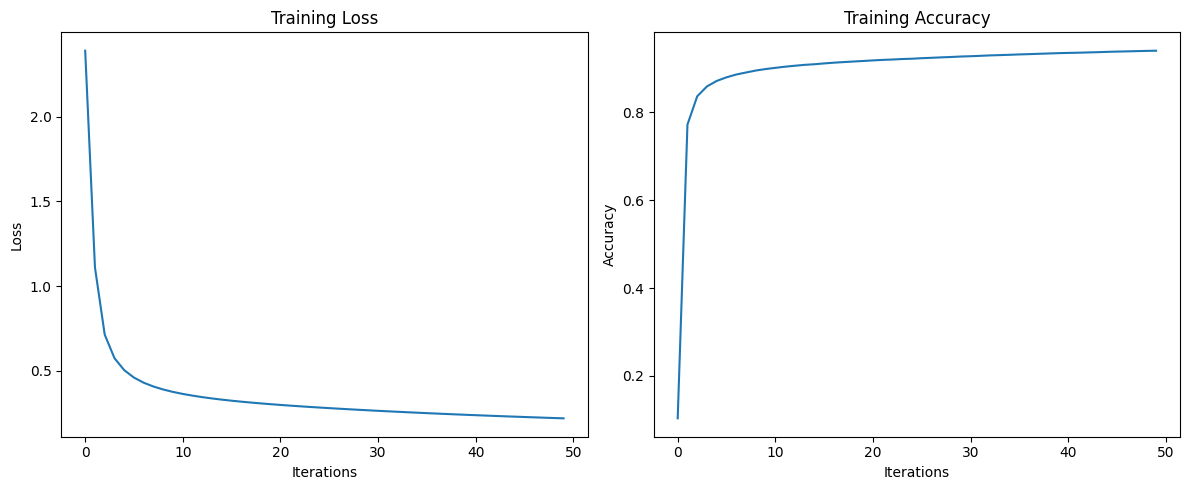

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Loss graph
ax[0].plot(loss_history)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("Loss")

# Accuracy graph
ax[1].plot(acc_history)
ax[1].set_title("Training Accuracy")
ax[1].set_xlabel("Iterations")
ax[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

Looking at the above graphs we can say our model is converging correctly

## Model Predictions on Validation Data

To evaluate how well the model performs, we visualize predictions on
some images from the validation set.

For each image we display:

- the handwritten digit
- the predicted label
- the true label


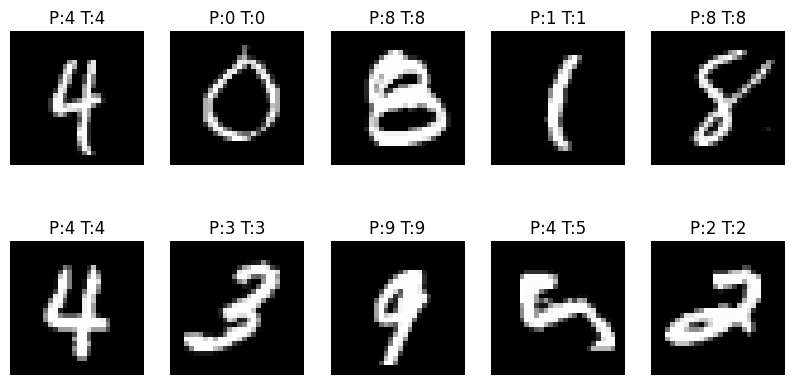

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

Z1, A1, Z2, A2 = foward_prop(W1, b1, W2, b2, X_dev)
predictions = np.argmax(A2, axis=0)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_dev[:, i].reshape(28, 28), cmap='gray')
    ax.set_title(f"P:{predictions[i]} T:{Y_dev[i]}")
    ax.axis('off')
    
plt.show()

## Misclassified Examples

To better understand the model's mistakes, we visualize some incorrectly
classified validation images.

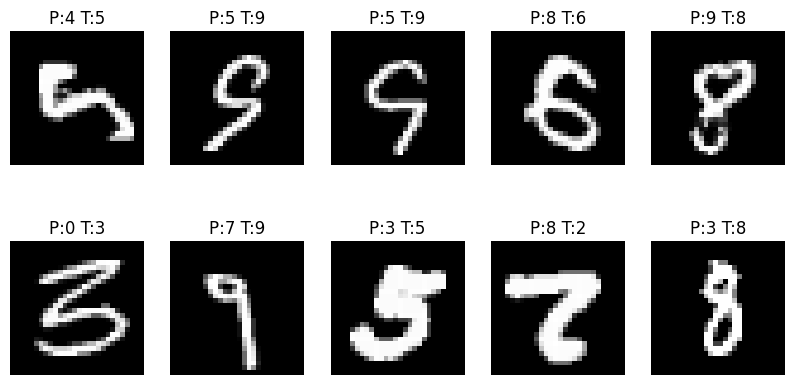

In [32]:
Z1, A1, Z2, A2 = foward_prop(W1, b1, W2, b2, X_dev)
predictions = np.argmax(A2, axis=0)

misclassified = np.where(predictions != Y_dev)[0]

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    idx = misclassified[i]
    ax.imshow(X_dev[:, idx].reshape(28,28), cmap="gray")
    ax.set_title(f"P:{predictions[idx]} T:{Y_dev[idx]}")
    ax.axis("off")

plt.show()

## Validating our NN over the validation data

In [42]:
Z1, A1, Z2, A2 = foward_prop(W1, b1, W2, b2, X_dev)

predictions_dev = np.argmax(A2, axis=0)

val_accuracy = np.mean(predictions_dev == Y_dev)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 94.00%


As a result our NN is achieving a 94.00% accuracy on our validation data that it have never seem before.

## Confusion Matrix

A confusion matrix shows how often each digit is predicted correctly
and which digits the model confuses with others.

Rows represent the **true labels** and columns represent the **predicted labels**.

This helps identify patterns in model errors.

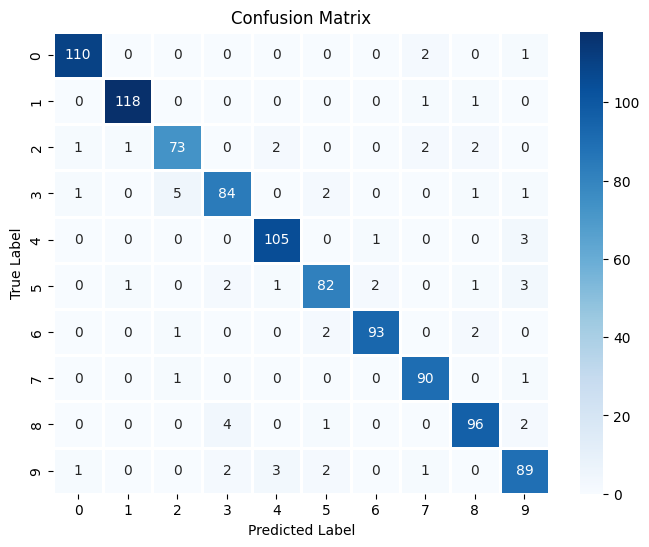

In [30]:
Z1, A1, Z2, A2 = foward_prop(W1, b1, W2, b2, X_dev)
predictions = np.argmax(A2, axis=0)

cm = confusion_matrix(Y_dev, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", linewidths=1)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Final Model Performance

After training for 500 iterations, the neural network achieved:

- **Validation Accuracy:** ~94%
- **Architecture:** 784 → 64 → 10
- **Activation:** ReLU (hidden layer), Softmax (output layer)
- **Loss Function:** Cross Entropy
- **Initialization:** He Initialization

The confusion matrix shows that most predictions lie along the diagonal,
indicating correct classification of digits.

Some confusion occurs between visually similar digits such as:
- 3 and 2
- 7 and 1
- 4 and 9

## Future Improvements

This implementation demonstrates how a neural network can be built
completely from scratch using NumPy.

Possible improvements include:

- Implement **mini-batch gradient descent**
- Add **more hidden layers**
- Implement advanced optimizers such as **Adam**
- Apply **regularization techniques**
- Use **Convolutional Neural Networks (CNNs)** for better performance on image data